In [ ]:
!pip install catboost -q
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

df1 = pd.read_csv("eur_ron_lunar.csv")
df2 = pd.read_csv("preturi_energie_lunare.csv")
df3 = pd.read_csv("date_complete_entsoe_pentru_ML.csv")

df = pd.merge(df1, df2, on = ["an", "luna"], how = "inner")
df = pd.merge(df, df3, on = ["an", "luna"], how = "inner")

df["criza_energetica"] = (df["an"].isin([2022, 2023])).astype(int)

#print(df.shape)
#print(df.head().T)

X = df.drop(columns=["an", "luna", "pret_energie_ron_mwh"])
Y = df["pret_energie_ron_mwh"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)
#model = RandomForestRegressor(n_estimators = 100, random_state = 42)
#model.fit(X_train, Y_train)

#y_pred = model.predict(X_test)

#print("R^2:", r2_score(Y_test, y_pred))
#print("MAE:", mean_absolute_error(Y_test, y_pred))
#print("MSE:", mean_squared_error(Y_test, y_pred))


#importanta = pd.DataFrame({
#    "Factor:": X.columns,
#    "Importanta:": model.feature_importances_ * 100
#}).sort_values("Importanta:", ascending = False)

#print(importanta)

modele = {
    "1. Regresie Liniara": LinearRegression(),
    "2. Ridge Regression": make_pipeline(StandardScaler(), Ridge(alpha = 1.0)),
    "3. SVR": make_pipeline(StandardScaler(), SVR(kernel = "rbf", C = 200)),
    "4. Random Forest": RandomForestRegressor(n_estimators = 100, random_state = 42),
    "5. Gradient Boosting": GradientBoostingRegressor(random_state = 42),
    "6. XGBoost": XGBRegressor(random_state = 42, objective="reg:squarederror"),
    "7. LightGMB": LGBMRegressor(random_state = 42, verbose = -1),
    "8. CatBoost": CatBoostRegressor(random_state = 42, verbose = 0),
}

rezultate = []


for nume_model, algoritm in modele.items():
    algoritm.fit(X_train, Y_train)
    predictii = algoritm.predict(X_test)
    r2 = r2_score(Y_test, predictii)
    mae = mean_absolute_error(Y_test, predictii)

    rezultate.append({
        "Model": nume_model,
        "Acuratete": round(r2, 4),
        "Eroare medie": round(mae, 4)
    })

df_clasament = pd.DataFrame(rezultate)
df_clasament = df_clasament.sort_values(by = "Acuratete", ascending = False).reset_index(drop = True)
print("TOP")
print("-"*60)
print(df_clasament.to_string())
print("-"*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
TOP
------------------------------------------------------------
                  Model  Acuratete  Eroare medie
0            6. XGBoost     0.8309      101.9854
1      4. Random Forest     0.8157      104.7612
2  5. Gradient Boosting     0.7994      111.2621
3           8. CatBoost     0.7449       96.1798
4   2. Ridge Regression     0.5912      161.4134
5   1. Regresie Liniara     0.5734      171.3122
6                3. SVR     0.3837      176.3772
7           7. LightGMB     0.2963      161.0349
------------------------------------------------------------


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df1 = pd.read_csv("eur_ron_lunar.csv")
df2 = pd.read_csv("preturi_energie_lunare.csv")
df3 = pd.read_csv("date_complete_entsoe_pentru_ML.csv")

df = pd.merge(df1, df2, on = ["an", "luna"], how = "inner")
df = pd.merge(df, df3, on = ["an", "luna"], how = "inner")

df["criza_energetica"] = (df["an"].isin([2022, 2023])).astype(int)

#print(df.shape)
#print(df.head().T)

X = df.drop(columns=["an", "luna", "pret_energie_ron_mwh"])
Y = df["pret_energie_ron_mwh"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)
model = XGBRegressor(random_state = 42, objective="reg:squarederror")
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

print("R^2:", r2_score(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("MSE:", mean_squared_error(Y_test, y_pred))


importanta = pd.DataFrame({
    "Factor:": X.columns,
    "Importanta:": model.feature_importances_ * 100
}).sort_values("Importanta:", ascending = False)

print(importanta)




R^2: 0.8308912953611365
MAE: 101.9853608954625
MSE: 41258.81990926802
                           Factor:  Importanta:
13                criza_energetica    90.050529
3        fossil_brown_coal_lignite     7.227834
0                    eur_ron_mediu     1.326043
1                          biomass     0.597846
4                       fossil_gas     0.320632
12            cerere_nationala_mwh     0.225688
5                 fossil_hard_coal     0.075123
7            hydro_water_reservoir     0.070631
6   hydro_run_of_river_and_pondage     0.045097
9                            solar     0.027666
11      productie_hidro_totala_mwh     0.015930
10                    wind_onshore     0.013312
8                          nuclear     0.003662
2                   energy_storage     0.000001


In [ ]:
model.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
parametrii_test = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgboost_baza = XGBRegressor(random_state = 42, objective = "reg:squarederror")

cautare = GridSearchCV(
    estimator = xgboost_baza,
    param_grid = parametrii_test,
    scoring = "r2",
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

cautare.fit(X_train, Y_train)
xgboost_tun = cautare.best_estimator_
predictii_tun = xgboost_tun.predict(X_test)

r2_tun = r2_score(Y_test, predictii_tun)
mae_tun = mean_absolute_error(Y_test, predictii_tun)

print(cautare.best_params_)
print(r2_tun)
print(mae_tun)


Fitting 5 folds for each of 384 candidates, totalling 1920 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
0.8441021647824949
96.50414891659658


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import pandas as pd


df1 = pd.read_csv("eur_ron_lunar.csv")
df2 = pd.read_csv("preturi_energie_lunare.csv")
df3 = pd.read_csv("date_complete_entsoe_pentru_ML.csv")

df = pd.merge(df1, df2, on = ["an", "luna"], how = "inner")
df = pd.merge(df, df3, on = ["an", "luna"], how = "inner")

#df["criza_energetica"] = (df["an"].isin([2022, 2023])).astype(int)
df = df[~df['an'].isin([2022, 2023])]

X = df.drop(columns=["an", "luna", "pret_energie_ron_mwh"])
Y = df["pret_energie_ron_mwh"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

model = XGBRegressor(colsample_bytree = 1.0, learning_rate = 0.2, max_depth = 3, n_estimators = 100, subsample = 1.0)

model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

print("R^2:", r2_score(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("MSE:", mean_squared_error(Y_test, y_pred))


importanta = pd.DataFrame({
    "Factor:": X.columns,
    "Importanta:": model.feature_importances_ * 100
}).sort_values("Importanta:", ascending = False)

print(importanta)

R^2: 0.9086288712738019
MAE: 32.10225093652613
MSE: 2439.858744436902
                           Factor:  Importanta:
0                    eur_ron_mediu    68.457664
6   hydro_run_of_river_and_pondage     8.700542
12            cerere_nationala_mwh     6.160160
1                          biomass     3.046876
11      productie_hidro_totala_mwh     2.819669
4                       fossil_gas     2.631069
9                            solar     2.164753
3        fossil_brown_coal_lignite     1.823537
7            hydro_water_reservoir     1.335652
5                 fossil_hard_coal     1.281869
10                    wind_onshore     0.687394
8                          nuclear     0.579465
2                   energy_storage     0.311344


In [ ]:
import statsmodels.api as sm
import pandas as pd

df1 = pd.read_csv("eur_ron_lunar.csv")
df2 = pd.read_csv("preturi_energie_lunare.csv")
df3 = pd.read_csv("date_complete_entsoe_pentru_ML.csv")

df = pd.merge(df1, df2, on = ["an", "luna"], how = "inner")
df = pd.merge(df, df3, on = ["an", "luna"], how = "inner")

df["criza_energetica"] = (df["an"].isin([2022, 2023])).astype(int)

variabile_indepenente = ["biomass", "energy_storage", "criza_energetica"]

X = df[variabile_indepenente]
Y = df["pret_energie_ron_mwh"]

model  = sm.OLS(Y, X)
rezultate = model.fit()
print(rezultate.summary())
print("\n--- Interpretarea coeficientilor ---")
for variabila, coef in zip(variabile_independente, rezultate.params[1:]):
    print(f"{variabila}: {coef:.4f}")

                                  OLS Regression Results                                 
Dep. Variable:     pret_energie_ron_mwh   R-squared (uncentered):                   0.780
Model:                              OLS   Adj. R-squared (uncentered):              0.774
Method:                   Least Squares   F-statistic:                              138.3
Date:                  Wed, 08 Apr 2026   Prob (F-statistic):                    2.62e-38
Time:                          17:48:48   Log-Likelihood:                         -831.73
No. Observations:                   120   AIC:                                      1669.
Df Residuals:                       117   BIC:                                      1678.
Df Model:                             3                                                  
Covariance Type:              nonrobust                                                  
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------

NameError: name 'variabile_independente' is not defined

In [ ]:
df['venit_lunar_estimat_hidro'] = df['productie_hidro_totala_mwh'] * df['pret_energie_ron_mwh']

venit_anual = df.groupby('an')['venit_lunar_estimat_hidro'].sum().reset_index()

venit_anual['venit_milioane_ron'] = venit_anual['venit_lunar_estimat_hidro'] / 1_000_000

print("--- Venituri Anuale Estimate (Proxy Hidroelectrica) ---")
print(venit_anual[['an', 'venit_milioane_ron']].round(2))

--- Venituri Anuale Estimate (Proxy Hidroelectrica) ---
     an  venit_milioane_ron
0  2015             5318.22
1  2016             2671.53
2  2017             3129.91
3  2018             3620.00
4  2019             3577.39
5  2020             2927.72
6  2021             3798.49
7  2025             6577.87


--- COMPARAȚIE: VENITURI REALE VS. VENITURI PIAȚĂ (PZU) ---
     an  venituri_mil_ron  venit_estimat_piata_mil  diferenta_%
0  2015              3329                  2658.93        25.20
1  2016              3396                  2671.56        27.12
2  2017              3288                  3130.14         5.04
3  2018              4351                  3620.35        20.18
4  2019              4177                  3577.64        16.75
5  2020              3850                  2927.80        31.50
6  2021              6699                  3797.89        76.39
7  2022              9452                 17760.33       -46.78
8  2023             12160                  9267.16        31.22
9  2024              9123                  6908.50        32.05


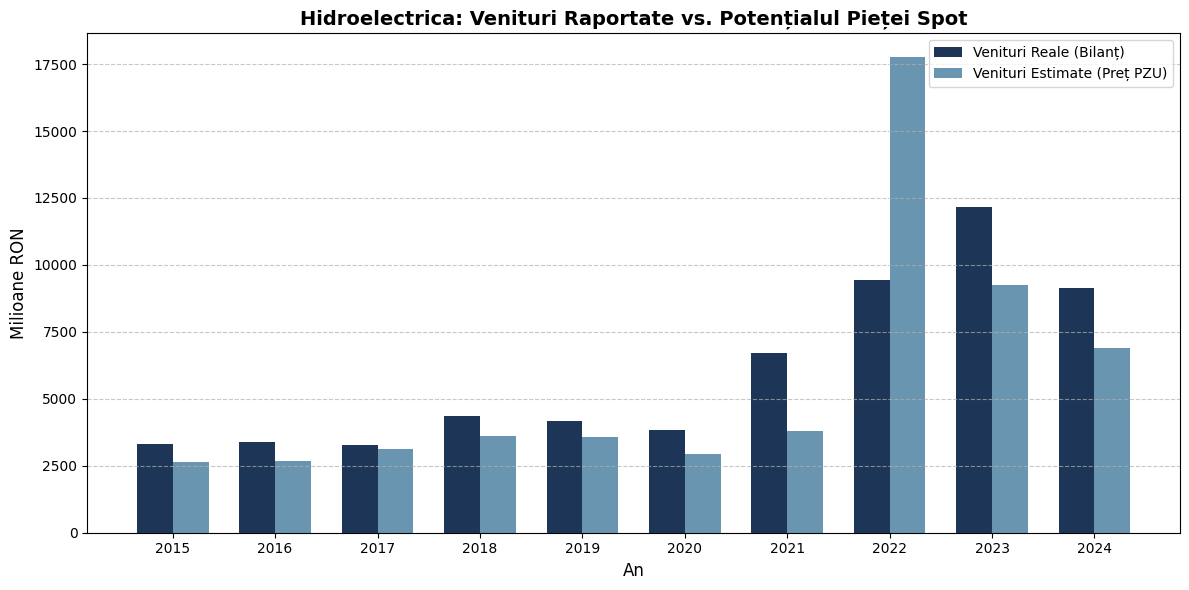

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_pret = pd.read_csv("preturi_energie_lunare.csv")
df_hidro = pd.read_csv("productie_hidro_lunara.csv")
df = pd.merge(df_pret, df_hidro, on=["an", "luna"], how="inner")

df_financiar = pd.read_csv("financiar_hidro.csv")

df['venit_piata_lunar_mil'] = (df['productie_hidro_totala_mwh'] * df['pret_energie_ron_mwh']) / 1_000_000

df_estimat_anual = df.groupby('an')['venit_piata_lunar_mil'].sum().reset_index()
df_estimat_anual.columns = ['an', 'venit_estimat_piata_mil']

df_final = pd.merge(df_financiar, df_estimat_anual, on="an", how="inner")

df_final['diferenta_%'] = ((df_final['venituri_mil_ron'] - df_final['venit_estimat_piata_mil']) / df_final['venit_estimat_piata_mil']) * 100

print("--- COMPARAȚIE: VENITURI REALE VS. VENITURI PIAȚĂ (PZU) ---")
print(df_final[['an', 'venituri_mil_ron', 'venit_estimat_piata_mil', 'diferenta_%']].round(2))

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = df_final['an']

plt.bar(index - bar_width/2, df_final['venituri_mil_ron'], bar_width, label='Venituri Reale (Bilanț)', color='#1d3557')
plt.bar(index + bar_width/2, df_final['venit_estimat_piata_mil'], bar_width, label='Venituri Estimate (Preț PZU)', color='#457b9d', alpha=0.8)

plt.xlabel('An', fontsize=12)
plt.ylabel('Milioane RON', fontsize=12)
plt.title('Hidroelectrica: Venituri Raportate vs. Potențialul Pieței Spot', fontsize=14, fontweight='bold')
plt.xticks(index)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- COMPARAȚIE: VENITURI REALE VS. VENITURI PIAȚĂ (PZU) ---
     an  venituri_mil_ron  venit_estimat_piata_mil  diferenta_%
0  2015              3329                  2658.93        25.20
1  2016              3396                  2671.56        27.12
2  2017              3288                  3130.14         5.04
3  2018              4351                  3620.35        20.18
4  2019              4177                  3577.64        16.75
5  2020              3850                  2927.80        31.50
6  2021              6699                  3797.89        76.39
7  2022              9452                 17760.33       -46.78
8  2023             12160                  9267.16        31.22
9  2024              9123                  6908.50        32.05


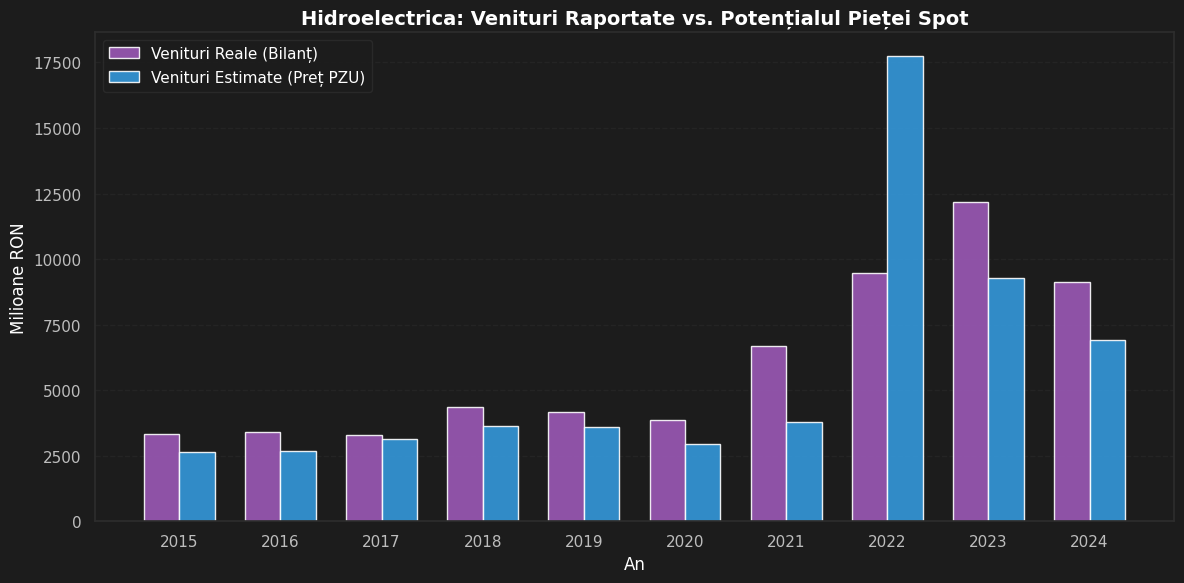

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_pret = pd.read_csv("preturi_energie_lunare.csv")
df_hidro = pd.read_csv("productie_hidro_lunara.csv")
df = pd.merge(df_pret, df_hidro, on=["an", "luna"], how="inner")

df_financiar = pd.read_csv("financiar_hidro.csv")

df['venit_piata_lunar_mil'] = (df['productie_hidro_totala_mwh'] * df['pret_energie_ron_mwh']) / 1_000_000

df_estimat_anual = df.groupby('an')['venit_piata_lunar_mil'].sum().reset_index()
df_estimat_anual.columns = ['an', 'venit_estimat_piata_mil']

df_final = pd.merge(df_financiar, df_estimat_anual, on="an", how="inner")

df_final['diferenta_%'] = ((df_final['venituri_mil_ron'] - df_final['venit_estimat_piata_mil']) / df_final['venit_estimat_piata_mil']) * 100

print("--- COMPARAȚIE: VENITURI REALE VS. VENITURI PIAȚĂ (PZU) ---")
print(df_final[['an', 'venituri_mil_ron', 'venit_estimat_piata_mil', 'diferenta_%']].round(2))

sns.set_theme(style="dark", rc={
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#1c1c1c",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "#bdbdbd",
    "ytick.color": "#bdbdbd",
    "grid.color": "#2d2d2d",
    "axes.edgecolor": "#2d2d2d"
})

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = df_final['an']

plt.bar(index - bar_width/2, df_final['venituri_mil_ron'], bar_width, label='Venituri Reale (Bilanț)', color='#9b59b6', alpha=0.9)
plt.bar(index + bar_width/2, df_final['venit_estimat_piata_mil'], bar_width, label='Venituri Estimate (Preț PZU)', color='#3498db', alpha=0.9)

plt.xlabel('An', fontsize=12)
plt.ylabel('Milioane RON', fontsize=12)
plt.title('Hidroelectrica: Venituri Raportate vs. Potențialul Pieței Spot', fontsize=14, fontweight='bold')
plt.xticks(index)

leg = plt.legend(facecolor='#1c1c1c', edgecolor='#2d2d2d')
plt.setp(leg.get_texts(), color='white')

plt.grid(axis='y', linestyle='--', alpha=0.5, color='#2d2d2d')
plt.tight_layout()
plt.show()

--- EVALUARE MODEL (PREDICȚIE VENIT LUNAR MIL. RON) ---
MAE (Eroarea Medie Absolută): 134.89
R2 Score: -0.93


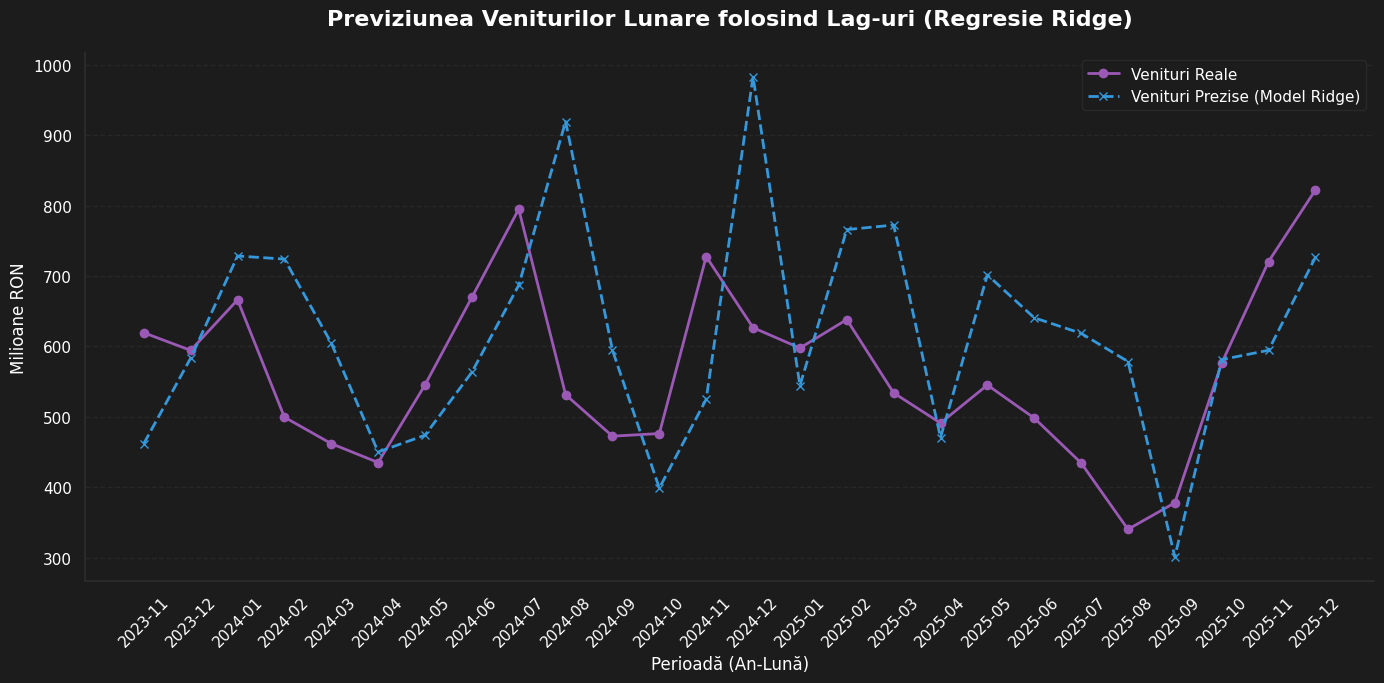

/tmp/ipykernel_14906/1841760896.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importanta_features.values, y=importanta_features.index, palette="viridis")


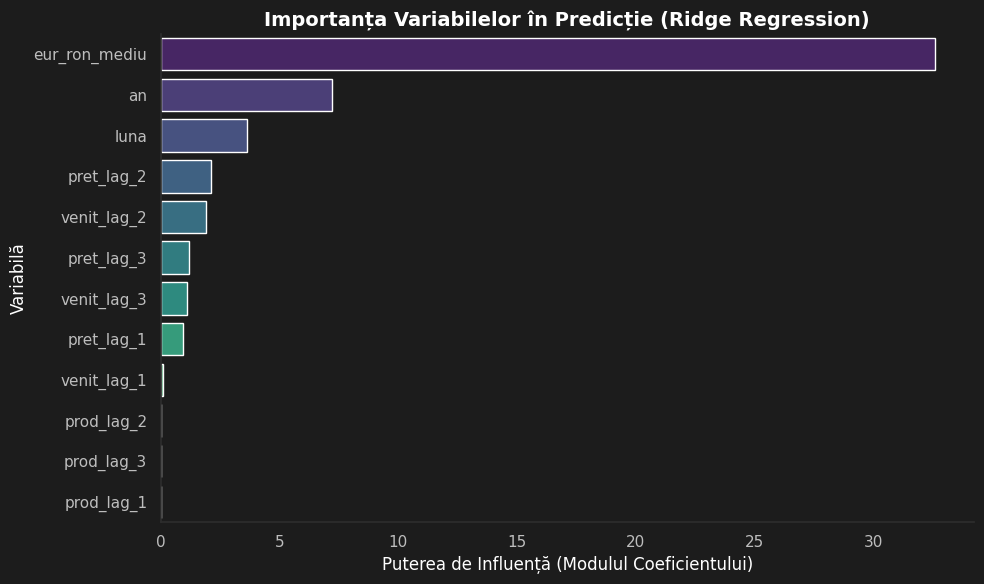

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_pret = pd.read_csv("preturi_energie_lunare.csv")
df_hidro = pd.read_csv("productie_hidro_lunara.csv")
df_euro = pd.read_csv("eur_ron_lunar.csv")

df = pd.merge(df_pret, df_hidro, on=["an", "luna"], how="inner")
df = pd.merge(df, df_euro[["an", "luna", "eur_ron_mediu"]], on=["an", "luna"], how="inner")

df['venit_lunar_mil'] = (df['productie_hidro_totala_mwh'] * df['pret_energie_ron_mwh']) / 1_000_000

df = df.sort_values(by=['an', 'luna']).reset_index(drop=True)

lag_features = [1, 2, 3]
for lag in lag_features:
    df[f'venit_lag_{lag}'] = df['venit_lunar_mil'].shift(lag)
    df[f'pret_lag_{lag}'] = df['pret_energie_ron_mwh'].shift(lag)
    df[f'prod_lag_{lag}'] = df['productie_hidro_totala_mwh'].shift(lag)

df_ml = df.dropna().copy()

features = [col for col in df_ml.columns if 'lag' in col] + ['eur_ron_mediu', 'luna', 'an']
X = df_ml[features]
y = df_ml['venit_lunar_mil']

split_idx = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
time_test = df_ml[['an', 'luna']].iloc[split_idx:]


model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

predictii = model.predict(X_test)

print("--- EVALUARE MODEL (PREDICȚIE VENIT LUNAR MIL. RON) ---")
print(f"MAE (Eroarea Medie Absolută): {mean_absolute_error(y_test, predictii):.2f}")
print(f"R2 Score: {r2_score(y_test, predictii):.2f}")

sns.set_theme(style="dark", rc={
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#1c1c1c",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "#bdbdbd",
    "ytick.color": "#bdbdbd",
    "grid.color": "#2d2d2d",
    "axes.edgecolor": "#2d2d2d"
})

plt.figure(figsize=(14, 7))

time_labels = time_test['an'].astype(str) + "-" + time_test['luna'].astype(str).str.zfill(2)

plt.plot(time_labels, y_test.values, label='Venituri Reale', color='#9b59b6', marker='o', linewidth=2)
plt.plot(time_labels, predictii, label='Venituri Prezise (Model Ridge)', color='#3498db', marker='x', linestyle='--', linewidth=2)

plt.title('Previziunea Veniturilor Lunare folosind Lag-uri (Regresie Ridge)', fontsize=16, fontweight='bold', color='white', pad=20)
plt.xlabel('Perioadă (An-Lună)', fontsize=12, color='white')
plt.ylabel('Milioane RON', fontsize=12, color='white')
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

leg = plt.legend(facecolor='#1c1c1c', edgecolor='#2d2d2d', fontsize=11)
plt.setp(leg.get_texts(), color='white')

plt.grid(axis='y', linestyle='--', alpha=0.3, color='#424242')
sns.despine()
plt.tight_layout()
plt.show()

importanta_features = pd.Series(np.abs(model.coef_), index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importanta_features.values, y=importanta_features.index, palette="viridis")
plt.title("Importanța Variabilelor în Predicție (Ridge Regression)", fontsize=14, fontweight='bold', color='white')
plt.xlabel("Puterea de Influență (Modulul Coeficientului)", color='white')
plt.ylabel("Variabilă", color='white')
sns.despine()
plt.tight_layout()
plt.show()